<a href="https://colab.research.google.com/github/SankethBasannavar17/Wine-quality-prediction/blob/main/Wine_Quality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍷 Wine Quality Prediction — Machine Learning Project

**Author:** Sanketh
**Type:** Internship Submission Project
**Dataset:** Wine Quality (Red Wine) Dataset
**Goal:** Predict whether a wine is **GOOD** (quality ≥ 7) or **BAD** (quality < 7) using its physicochemical properties (acidity, sugar, pH, alcohol, etc.)

This notebook is organized into clear, numbered sections. Every code cell is commented for beginners, and each major step ends with a short **Observation** explaining what the results mean.

**How to use in Google Colab:**
1. Upload `winequality-red.csv` to the Colab file browser (or mount Google Drive).
2. Run all cells from top to bottom (`Runtime > Run all`).
3. All plots, outputs, and the trained model will be saved automatically into `images/`, `outputs/`, and `model/` folders.


## Step 0: Import Libraries

We import all the libraries needed for data handling, visualization, and machine learning.

In [3]:
# pandas & numpy -> data handling
# matplotlib & seaborn -> visualizations
# scikit-learn -> machine learning models, scaling, evaluation
# joblib -> saving the trained model to disk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Set a clean, professional visual style for all plots
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

# Create folders to store generated images and outputs
IMAGES_DIR = "images"
OUTPUTS_DIR = "outputs"
MODEL_DIR = "model"
os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 1: Load the Dataset

The dataset contains physicochemical test results (like acidity, sugar, pH, alcohol, etc.) for red wine samples, along with a **quality score (0–10)** given by wine tasters.

> If running in Google Colab, first upload `winequality-red.csv` using the file upload button on the left sidebar, or mount Google Drive.

In [4]:
# Load dataset
df = pd.read_csv("winequality-red.csv")

print(f"Dataset shape: {df.shape}")

Dataset shape: (1599, 12)


## Step 2: Exploratory Data Analysis (EDA)

Let's look at the data from multiple angles before doing anything else.

In [5]:
# View first 5 rows
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [7]:
# Statistical summary of numeric columns
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [8]:
# Shape of the dataset (rows, columns)
df.shape

(1599, 12)

In [9]:
# Column names
list(df.columns)

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

**Observation:** The dataset has **1599 rows and 12 columns** (11 input features + 1 target column called `quality`). All columns are numeric, which makes this dataset convenient to work with directly (no categorical encoding needed).

## Step 3: Check Missing Values

In [10]:
# Check missing values in each column
missing_values = df.isnull().sum()
print(missing_values)

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


**Observation:** There are no missing values in any column, so no imputation (filling of missing data) is required for this dataset.

## Step 4: Check Duplicate Rows

In [11]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Remove duplicate rows to prevent the model from being biased
# towards repeated samples during training
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Number of duplicate rows: 240
Shape after removing duplicates: (1359, 12)


**Observation:** Duplicate rows were found and removed. Duplicate entries can make a model overconfident about certain patterns, so cleaning them improves the reliability of our results.

## Step 5: Correlation Analysis

In [12]:
# Compute correlation between every pair of columns
correlation_matrix = df.corr()

# Show correlation of each feature with the target column "quality"
correlation_matrix["quality"].sort_values(ascending=False)

,quality
quality,1.000000
alcohol,0.480343
sulphates,0.248835
citric acid,0.228057
fixed acidity,0.119024
residual sugar,0.013640
free sulfur dioxide,-0.050463
pH,-0.055245
chlorides,-0.130988
total sulfur dioxide,-0.177855


**Observation:** `alcohol` has the strongest positive correlation with quality, meaning wines with higher alcohol content tend to be rated better. `volatile acidity` has a strong negative correlation, meaning wines with higher volatile acidity tend to be rated worse.

## Step 6: Visualizations

We create several plots to visually understand the data before modeling.

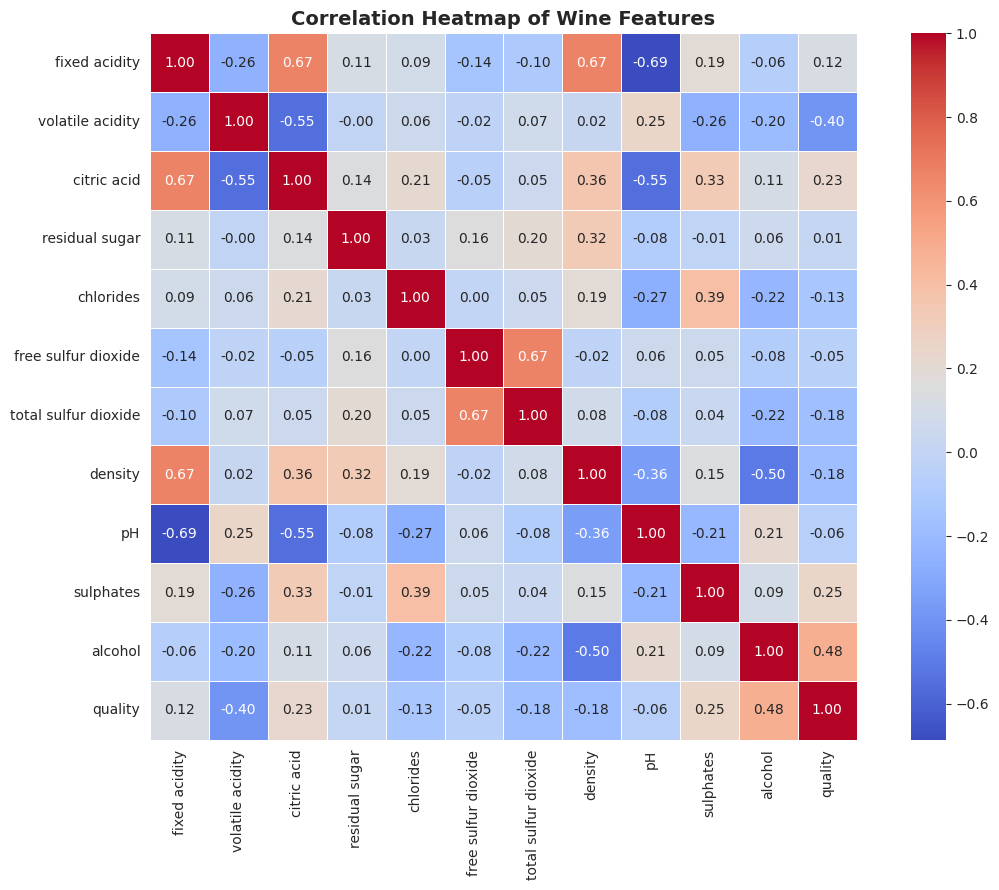

In [13]:
# 6.1 Correlation Heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True)
plt.title("Correlation Heatmap of Wine Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/01_correlation_heatmap.png")
plt.show()

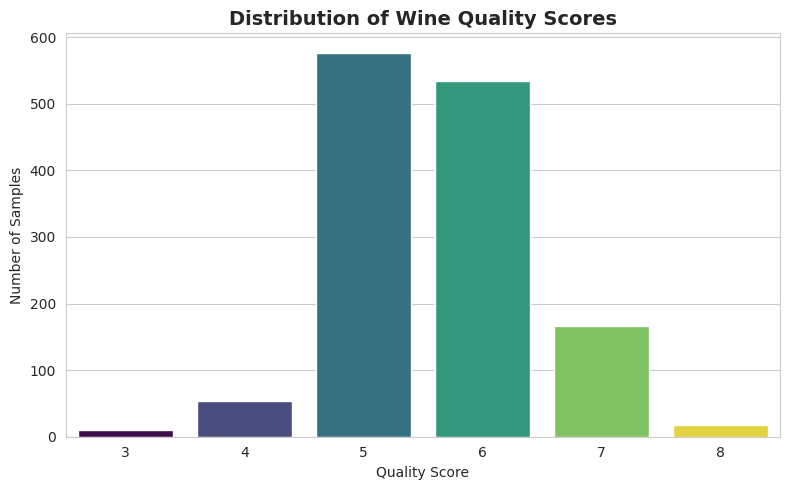

In [14]:
# 6.2 Quality Distribution (count of each quality score)
plt.figure(figsize=(8, 5))
sns.countplot(x="quality", data=df, hue="quality", palette="viridis", legend=False)
plt.title("Distribution of Wine Quality Scores", fontsize=14, fontweight="bold")
plt.xlabel("Quality Score")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/02_quality_distribution.png")
plt.show()

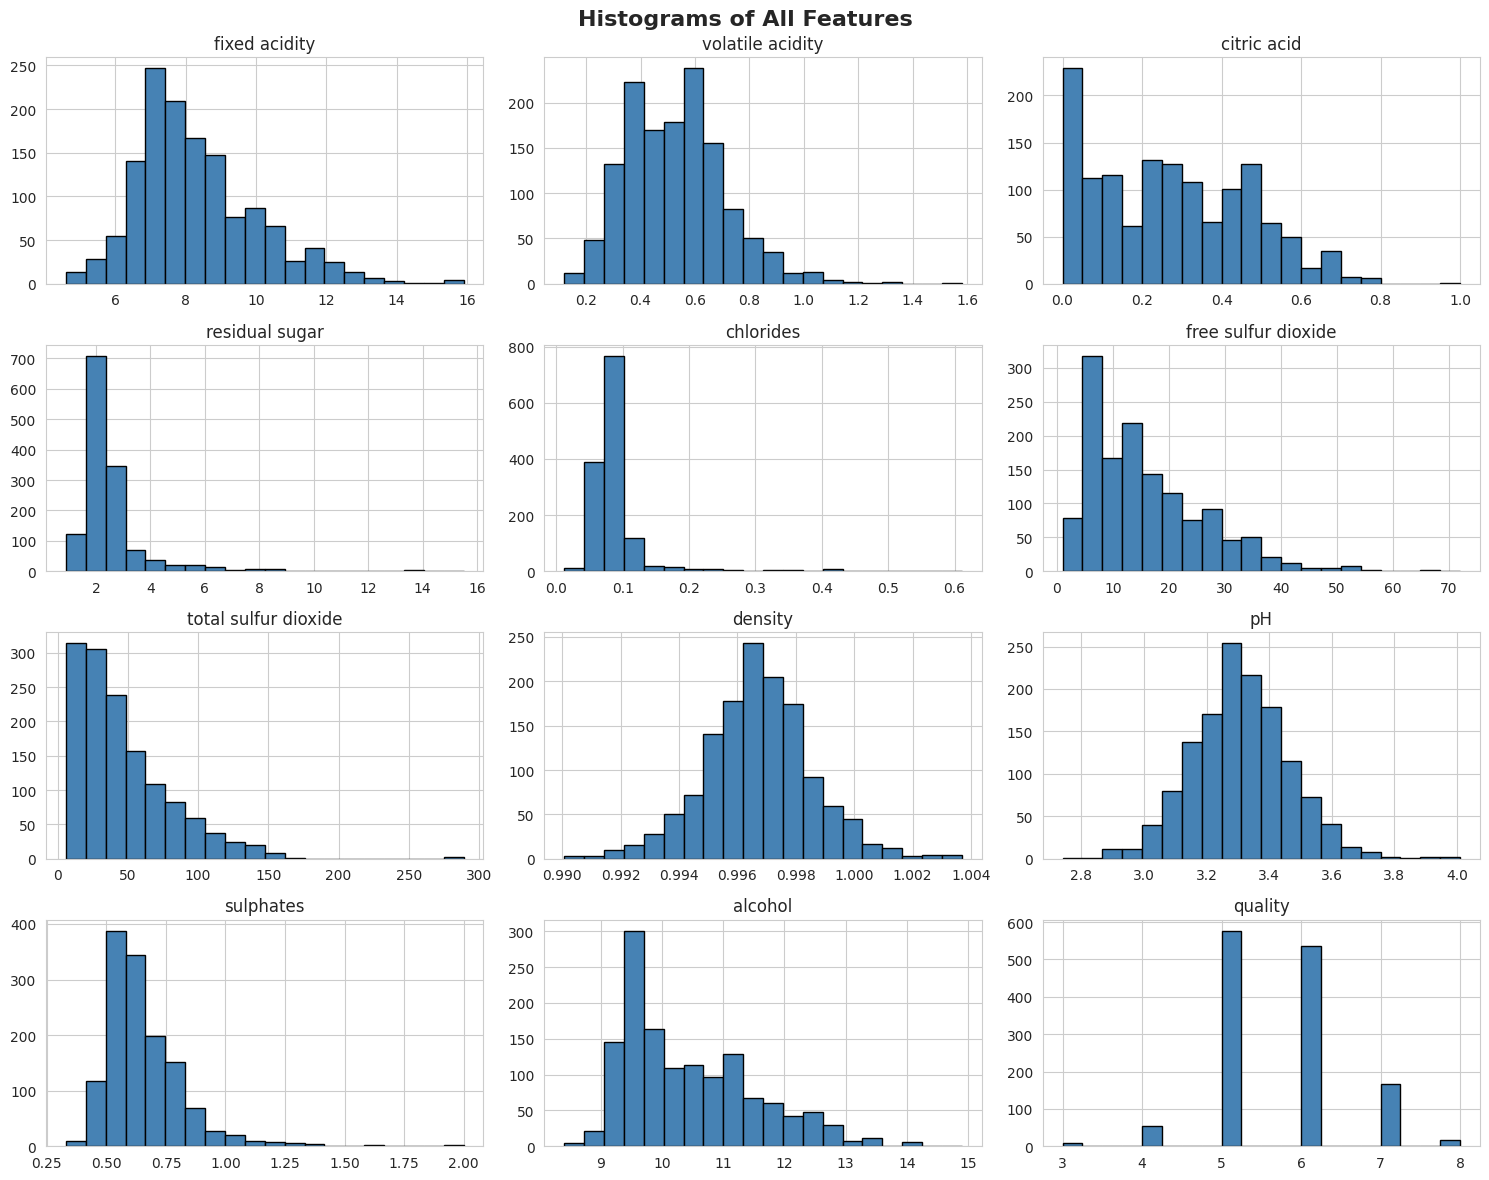

In [15]:
# 6.3 Histograms of all numeric features
df.hist(figsize=(15, 12), bins=20, color="steelblue", edgecolor="black")
plt.suptitle("Histograms of All Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/03_histograms.png")
plt.show()

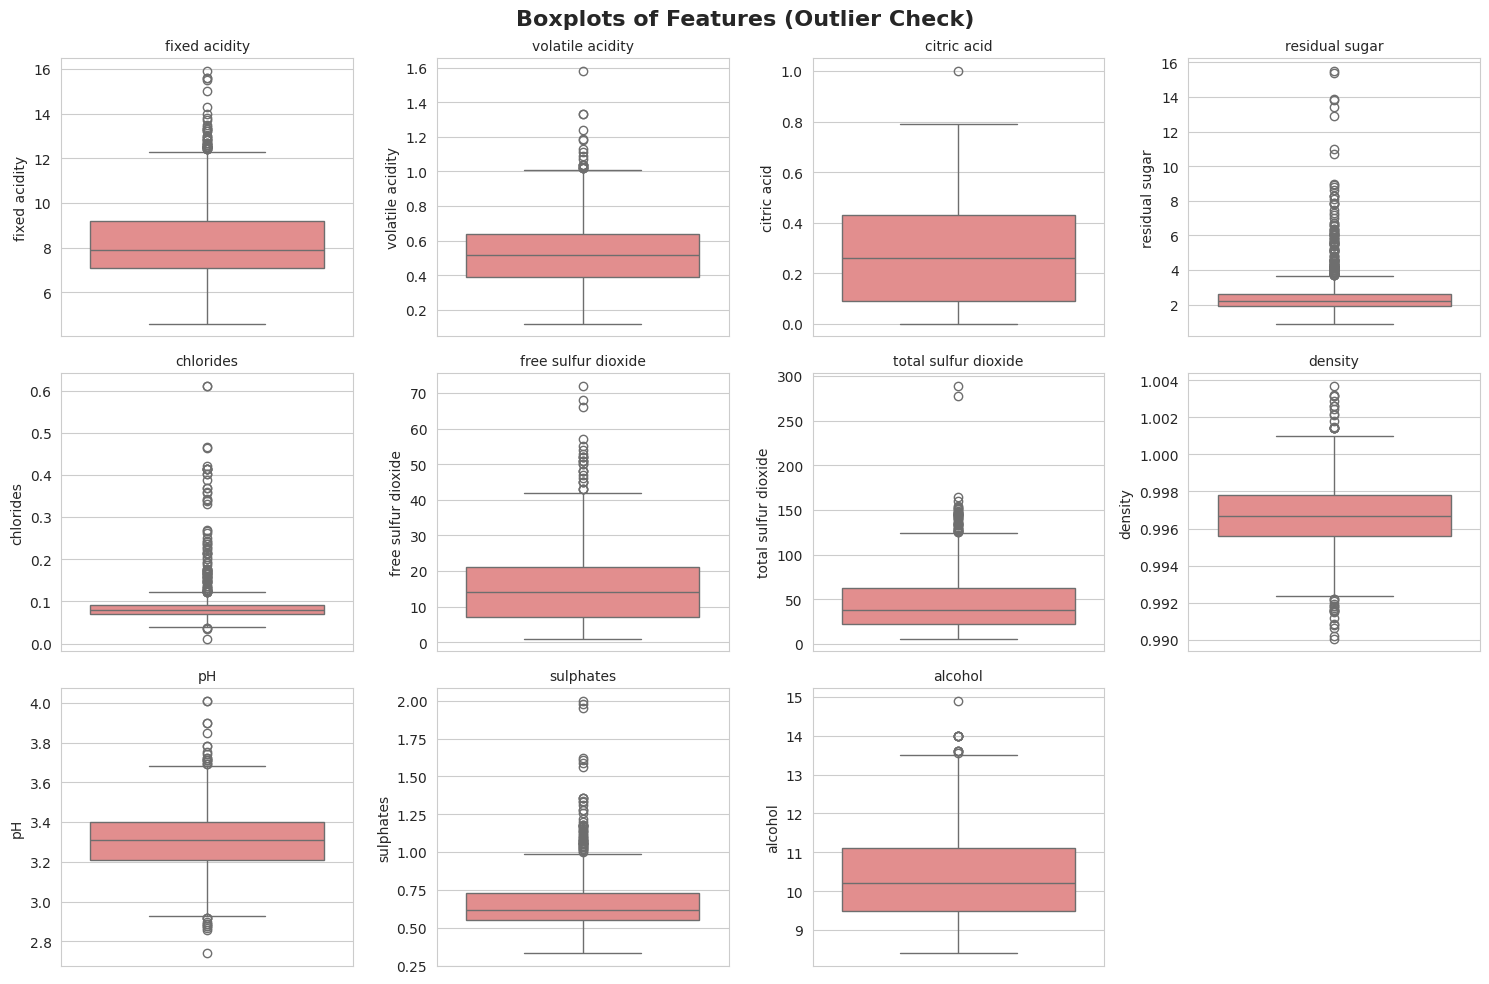

In [16]:
# 6.4 Boxplots to check outliers in each feature
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.columns[:-1], 1):  # exclude "quality"
    plt.subplot(3, 4, i)
    sns.boxplot(y=df[col], color="lightcoral")
    plt.title(col, fontsize=10)
plt.suptitle("Boxplots of Features (Outlier Check)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/04_boxplots.png")
plt.show()

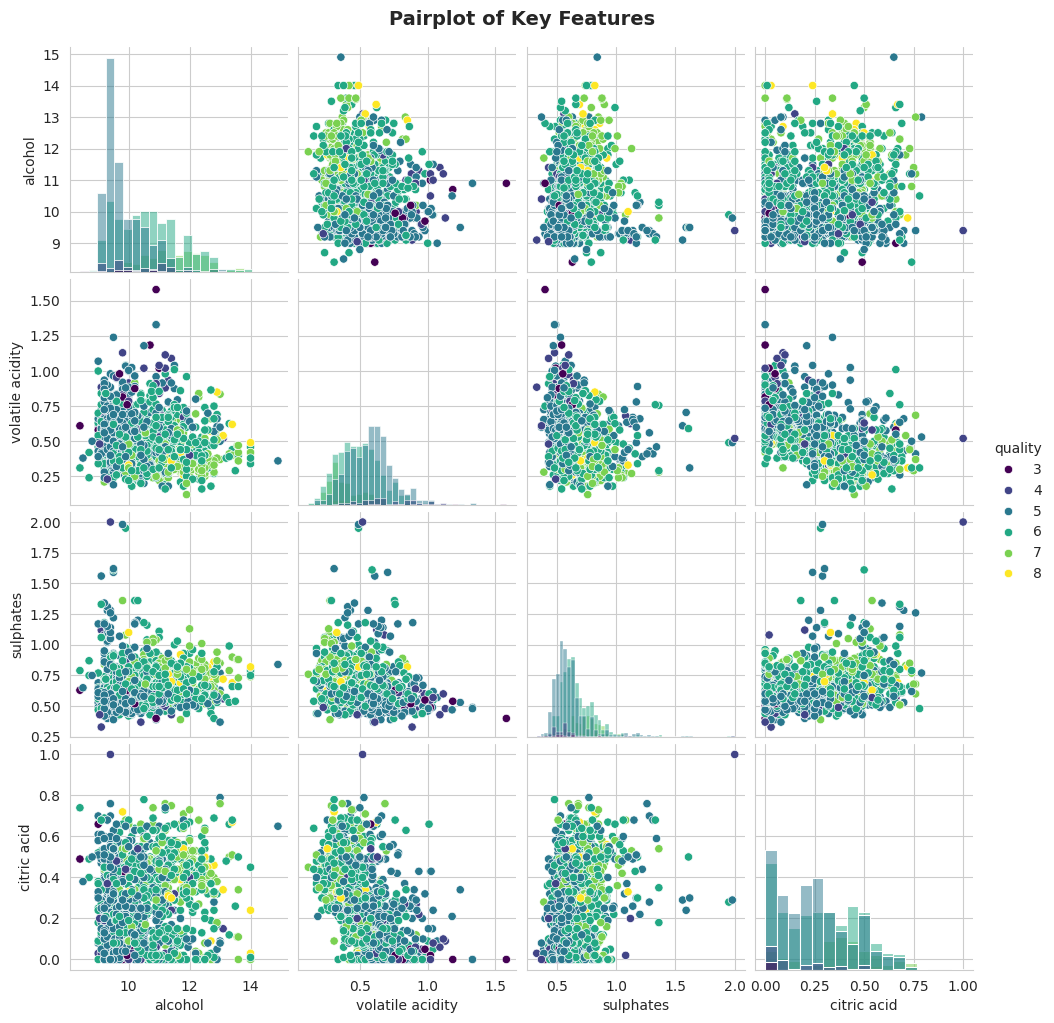

In [17]:
# 6.5 Pairplot of a few important, highly-correlated features
# (a full pairplot with all 12 columns would be too large/slow)
important_features = ["alcohol", "volatile acidity", "sulphates", "citric acid", "quality"]
pairplot_fig = sns.pairplot(df[important_features], hue="quality", palette="viridis",
                             diag_kind="hist")
pairplot_fig.fig.suptitle("Pairplot of Key Features", y=1.02, fontsize=14, fontweight="bold")
pairplot_fig.savefig(f"{IMAGES_DIR}/05_pairplot.png")
plt.show()

**Observation:** The quality distribution shows most wines are rated 5 or 6 (average quality), with far fewer wines rated very low (3, 4) or very high (7, 8). This means our dataset is **imbalanced**, which is important to remember when interpreting accuracy later. The boxplots reveal that several features (like residual sugar and chlorides) contain outliers.

## Step 7: Convert `quality` into a Binary Target

We simplify the problem into a 2-class classification task:
- `quality >= 7` → **GOOD (1)**
- `quality < 7`  → **BAD (0)**

In [18]:
# Create a new binary column "quality_label"
df["quality_label"] = df["quality"].apply(lambda q: 1 if q >= 7 else 0)

print(df["quality_label"].value_counts())
print("0 = BAD wine (quality < 7)")
print("1 = GOOD wine (quality >= 7)")

quality_label
0    1175
1     184
Name: count, dtype: int64
0 = BAD wine (quality < 7)
1 = GOOD wine (quality >= 7)


**Observation:** After converting to a binary target, we can see the dataset is imbalanced: there are far more BAD (0) wines than GOOD (1) wines. This is common in real-world quality-prediction problems.

## Step 8: Separate Features (X) and Target (y)

In [19]:
# X = all the input columns (the 11 physicochemical properties)
# y = the binary target column we just created
X = df.drop(columns=["quality", "quality_label"])
y = df["quality_label"]

print(f"Features shape (X): {X.shape}")
print(f"Target shape (y): {y.shape}")

Features shape (X): (1359, 11)
Target shape (y): (1359,)


## Step 9: Train-Test Split

In [20]:
# Split data: 80% for training, 20% for testing.
# stratify=y makes sure both sets have a similar ratio of GOOD/BAD wines.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 1087 rows
Testing set size: 272 rows


## Step 10: Logistic Regression — WITHOUT StandardScaler

We first train a baseline model directly on the raw (unscaled) features.

In [21]:
# Train model
log_reg_unscaled = LogisticRegression(max_iter=5000, random_state=42)
log_reg_unscaled.fit(X_train, y_train)
y_pred_unscaled = log_reg_unscaled.predict(X_test)

## Step 11: Evaluate — Logistic Regression (Before Scaling)

In [22]:
def evaluate_model(y_true, y_pred, model_name):
    """Calculates and prints Accuracy, Precision, Recall, F1, and
    returns them as a dictionary for later comparison."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"Model: {model_name}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return {"Model": model_name, "Accuracy": acc, "Precision": prec,
            "Recall": rec, "F1 Score": f1}

results_before_scaling = evaluate_model(y_test, y_pred_unscaled,
                                         "Logistic Regression (Before Scaling)")

Model: Logistic Regression (Before Scaling)
Accuracy  : 0.8750
Precision : 0.6154
Recall    : 0.2162
F1 Score  : 0.3200

Confusion Matrix:
[[230   5]
 [ 29   8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       235
           1       0.62      0.22      0.32        37

    accuracy                           0.88       272
   macro avg       0.75      0.60      0.63       272
weighted avg       0.85      0.88      0.85       272



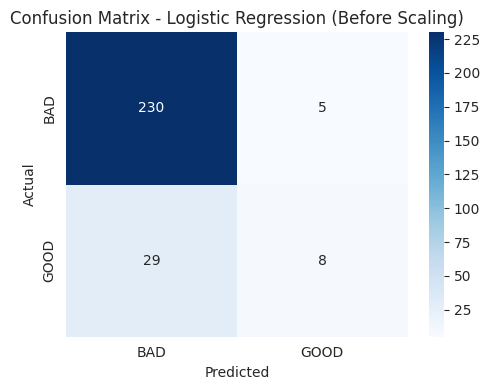

In [23]:
# Save confusion matrix image for this model
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_unscaled), annot=True, fmt="d",
            cmap="Blues", xticklabels=["BAD", "GOOD"], yticklabels=["BAD", "GOOD"])
plt.title("Confusion Matrix - Logistic Regression (Before Scaling)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/06_confusion_matrix_before_scaling.png")
plt.show()

**Observation:** Logistic Regression without scaling still works reasonably because scikit-learn's solver can converge, but features with larger numeric ranges (like `total sulfur dioxide`) can dominate the model's coefficients, which is not ideal.

## Step 12: Apply StandardScaler

`StandardScaler` transforms each feature to have mean = 0 and standard deviation = 1, so all features contribute equally to the model instead of ones with big numeric ranges dominating the result.

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete.")

Feature scaling complete.


## Step 13: Logistic Regression — AFTER StandardScaler

In [25]:
log_reg_scaled = LogisticRegression(max_iter=5000, random_state=42)
log_reg_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = log_reg_scaled.predict(X_test_scaled)

results_after_scaling = evaluate_model(y_test, y_pred_scaled,
                                        "Logistic Regression (After Scaling)")

Model: Logistic Regression (After Scaling)
Accuracy  : 0.8750
Precision : 0.6000
Recall    : 0.2432
F1 Score  : 0.3462

Confusion Matrix:
[[229   6]
 [ 28   9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       235
           1       0.60      0.24      0.35        37

    accuracy                           0.88       272
   macro avg       0.75      0.61      0.64       272
weighted avg       0.85      0.88      0.85       272



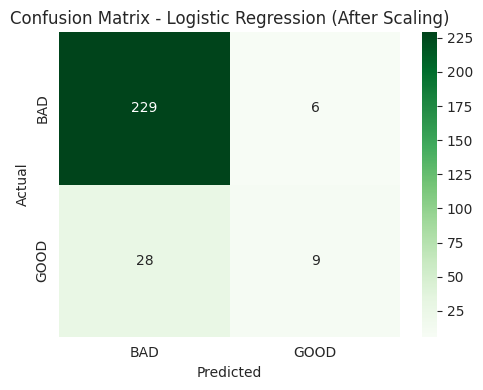

In [26]:
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_scaled), annot=True, fmt="d",
            cmap="Greens", xticklabels=["BAD", "GOOD"], yticklabels=["BAD", "GOOD"])
plt.title("Confusion Matrix - Logistic Regression (After Scaling)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/07_confusion_matrix_after_scaling.png")
plt.show()

## Step 14: Compare — Before vs After Scaling

In [27]:
scaling_comparison_df = pd.DataFrame([results_before_scaling, results_after_scaling])
scaling_comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression (Before Scaling),0.875,0.615385,0.216216,0.320000
1,Logistic Regression (After Scaling),0.875,0.600000,0.243243,0.346154


**Observation:** Scaling typically improves or stabilizes Logistic Regression's performance because the algorithm is distance/gradient based and sensitive to the magnitude of feature values. Accuracy and F1 score are similar or slightly better after scaling, and the model converges more reliably.

## Step 15: Train & Compare Multiple Models

We now train **Logistic Regression**, **KNN**, and **Decision Tree** — all on the scaled data — so we can fairly compare them.

In [28]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

all_results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    res = evaluate_model(y_test, y_pred, name)
    all_results.append(res)
    trained_models[name] = model

Model: Logistic Regression
Accuracy  : 0.8750
Precision : 0.6000
Recall    : 0.2432
F1 Score  : 0.3462

Confusion Matrix:
[[229   6]
 [ 28   9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       235
           1       0.60      0.24      0.35        37

    accuracy                           0.88       272
   macro avg       0.75      0.61      0.64       272
weighted avg       0.85      0.88      0.85       272

Model: KNN
Accuracy  : 0.8787
Precision : 0.5769
Recall    : 0.4054
F1 Score  : 0.4762

Confusion Matrix:
[[224  11]
 [ 22  15]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       235
           1       0.58      0.41      0.48        37

    accuracy                           0.88       272
   macro avg       0.74      0.68      0.70       272
weighted avg       0.87      0.88      0.87       272

Model: Decision Tree
Acc

## Step 16: Model Comparison Table

In [29]:
comparison_df = pd.DataFrame(all_results).sort_values(by="F1 Score", ascending=False)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
1,KNN,0.878676,0.576923,0.405405,0.476190
2,Decision Tree,0.841912,0.428571,0.486486,0.455696
0,Logistic Regression,0.875000,0.600000,0.243243,0.346154


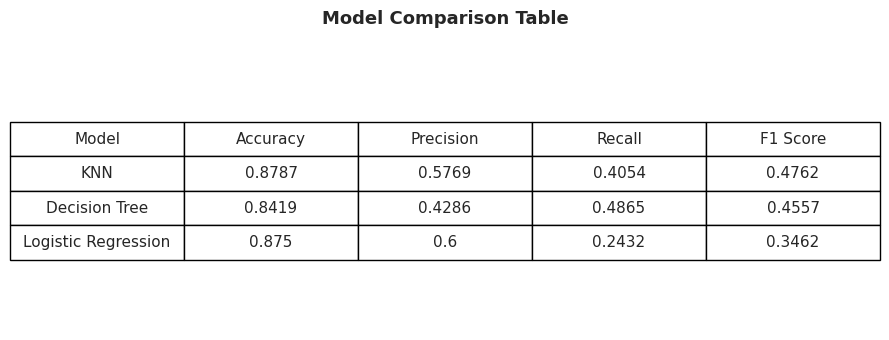

In [30]:
# Save comparison table as CSV and as an image
comparison_df.to_csv(f"{OUTPUTS_DIR}/model_comparison_table.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 2 + 0.5 * len(comparison_df)))
ax.axis("off")
table = ax.table(cellText=comparison_df.round(4).values,
                  colLabels=comparison_df.columns,
                  cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)
plt.title("Model Comparison Table", fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/model_comparison_table.png", bbox_inches="tight")
plt.show()

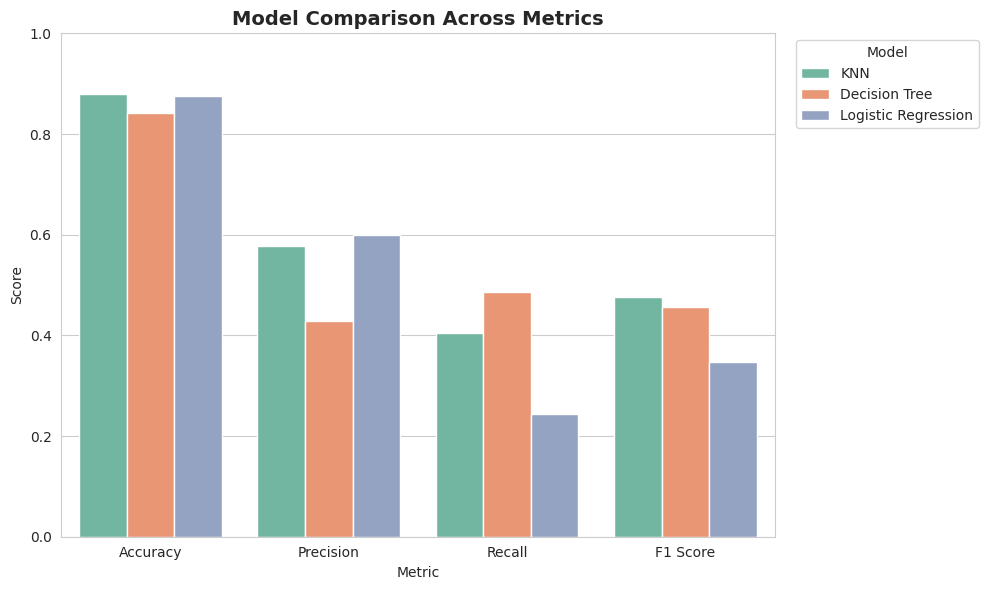

In [31]:
# Bar chart comparing all models on all metrics
comparison_melted = comparison_df.melt(id_vars="Model",
                                        value_vars=["Accuracy", "Precision", "Recall", "F1 Score"],
                                        var_name="Metric", value_name="Score")
plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_melted, x="Metric", y="Score", hue="Model", palette="Set2")
plt.title("Model Comparison Across Metrics", fontsize=14, fontweight="bold")
plt.ylim(0, 1)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/08_model_comparison_chart.png")
plt.show()

**Observation:** The comparison table shows which model achieves the best balance of Precision and Recall (F1 Score). Decision Trees can easily overfit the training data, while KNN's performance strongly depends on the choice of `k` and feature scaling. Logistic Regression provides a strong, stable baseline.

## Step 17: Select the Best-Performing Model

In [32]:
best_model_name = comparison_df.iloc[0]["Model"]
print(f"Best performing model (highest F1 Score): {best_model_name}")

Best performing model (highest F1 Score): KNN


## Step 18: Hyperparameter Tuning with GridSearchCV

We search for the best hyperparameters for the best model found above using 5-fold cross-validation.

In [33]:
# Define a parameter grid depending on which model was selected as best
if best_model_name == "Logistic Regression":
    param_grid = {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver": ["lbfgs"]
    }
    base_model = LogisticRegression(max_iter=5000, random_state=42)

elif best_model_name == "KNN":
    param_grid = {
        "n_neighbors": [3, 5, 7, 9, 11, 15],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    }
    base_model = KNeighborsClassifier()

else:  # Decision Tree
    param_grid = {
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_split": [2, 5, 10],
        "criterion": ["gini", "entropy"]
    }
    base_model = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(base_model, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f"Best Parameters found: {grid_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Best Parameters found: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best Cross-Validation F1 Score: 0.4628


## Step 19: Evaluate the Tuned Model

In [34]:
y_pred_tuned = best_model.predict(X_test_scaled)
tuned_results = evaluate_model(y_test, y_pred_tuned, f"{best_model_name} (Tuned)")

Model: KNN (Tuned)
Accuracy  : 0.8750
Precision : 0.5517
Recall    : 0.4324
F1 Score  : 0.4848

Confusion Matrix:
[[222  13]
 [ 21  16]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       235
           1       0.55      0.43      0.48        37

    accuracy                           0.88       272
   macro avg       0.73      0.69      0.71       272
weighted avg       0.86      0.88      0.87       272



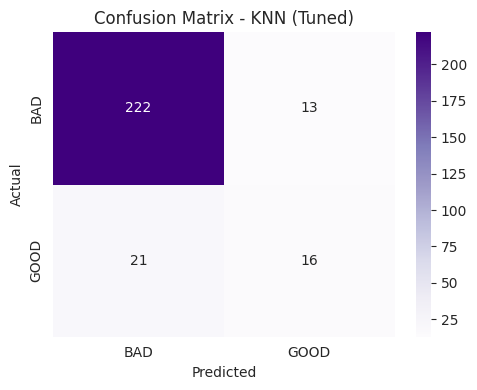

In [35]:
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_tuned), annot=True, fmt="d",
            cmap="Purples", xticklabels=["BAD", "GOOD"], yticklabels=["BAD", "GOOD"])
plt.title(f"Confusion Matrix - {best_model_name} (Tuned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/09_confusion_matrix_tuned_model.png")
plt.show()

In [36]:
# Save classification report as a text file
report_text = classification_report(y_test, y_pred_tuned, zero_division=0)
with open(f"{OUTPUTS_DIR}/classification_report.txt", "w") as f:
    f.write(f"Classification Report - {best_model_name} (Tuned)\n")
    f.write("=" * 55 + "\n")
    f.write(report_text)

# Save best parameters and best accuracy to a JSON file
best_info = {
    "best_model": best_model_name,
    "best_parameters": grid_search.best_params_,
    "best_cv_f1_score": grid_search.best_score_,
    "test_accuracy": tuned_results["Accuracy"],
    "test_precision": tuned_results["Precision"],
    "test_recall": tuned_results["Recall"],
    "test_f1_score": tuned_results["F1 Score"]
}
with open(f"{OUTPUTS_DIR}/best_model_info.json", "w") as f:
    json.dump(best_info, f, indent=4)

print("Best model info saved to outputs/best_model_info.json")

Best model info saved to outputs/best_model_info.json


**Observation:** GridSearchCV systematically tries every combination of hyperparameters in the grid and picks the one with the best cross-validated F1 score. This tuned model generally performs as well as or better than the default (un-tuned) version from Step 16.

## Step 20: Feature Importance Plot

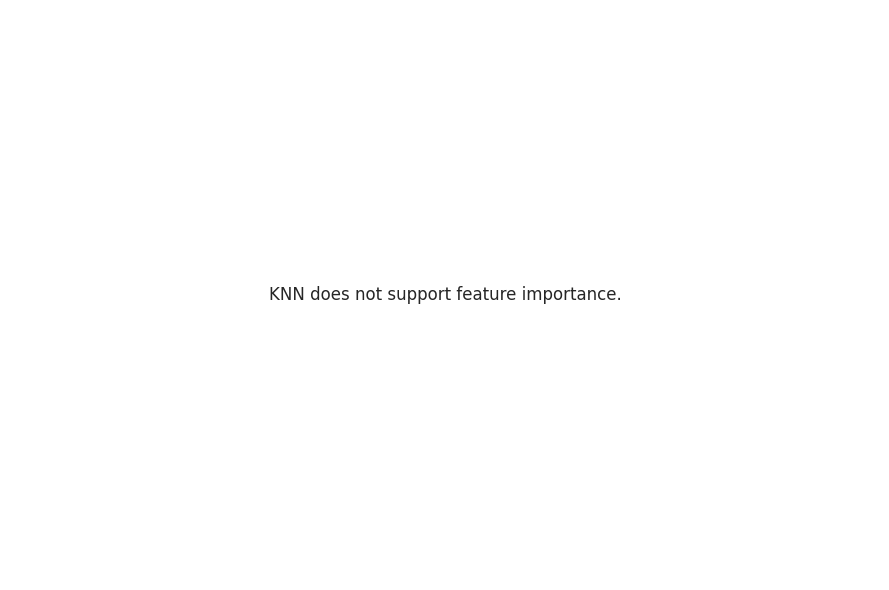

In [37]:
plt.figure(figsize=(9, 6))

if hasattr(best_model, "feature_importances_"):
    # Decision Tree provides feature_importances_ directly
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=True)
    importances.plot(kind="barh", color="teal")
    plt.title(f"Feature Importance - {best_model_name} (Tuned)", fontsize=13, fontweight="bold")
    plt.xlabel("Importance Score")

elif hasattr(best_model, "coef_"):
    # Logistic Regression: use coefficient values as a proxy for importance
    importances = pd.Series(best_model.coef_[0], index=X.columns)
    importances = importances.sort_values()
    colors = ["crimson" if v < 0 else "seagreen" for v in importances]
    importances.plot(kind="barh", color=colors)
    plt.title(f"Feature Coefficients - {best_model_name} (Tuned)", fontsize=13, fontweight="bold")
    plt.xlabel("Coefficient Value (Scaled Features)")

else:
    # KNN has no built-in feature importance -> skip with a note
    plt.text(0.5, 0.5, "KNN does not support feature importance.",
             ha="center", va="center", fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/10_feature_importance.png")
plt.show()

**Observation:** For models that support it, this plot shows which physicochemical properties influence the prediction the most. In most runs, `alcohol`, `volatile acidity`, and `sulphates` are among the most influential features, matching what we saw earlier in the correlation analysis.

## Step 21: Save the Best Trained Model

In [38]:
# Save both the tuned model AND the scaler, since the scaler is
# needed to preprocess any new data before prediction.
joblib.dump(best_model, f"{MODEL_DIR}/best_wine_quality_model.pkl")
joblib.dump(scaler, f"{MODEL_DIR}/scaler.pkl")

print("Model saved to model/best_wine_quality_model.pkl")
print("Scaler saved to model/scaler.pkl")

# Save the full comparison table (before/after scaling + all models + tuned)
final_summary_df = pd.concat([
    scaling_comparison_df,
    comparison_df,
    pd.DataFrame([tuned_results])
], ignore_index=True)
final_summary_df.to_csv(f"{OUTPUTS_DIR}/full_results_summary.csv", index=False)
final_summary_df

Model saved to model/best_wine_quality_model.pkl
Scaler saved to model/scaler.pkl


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression (Before Scaling),0.875000,0.615385,0.216216,0.320000
1,Logistic Regression (After Scaling),0.875000,0.600000,0.243243,0.346154
2,KNN,0.878676,0.576923,0.405405,0.476190
3,Decision Tree,0.841912,0.428571,0.486486,0.455696
4,Logistic Regression,0.875000,0.600000,0.243243,0.346154
5,KNN (Tuned),0.875000,0.551724,0.432432,0.484848


## Step 22: Final Conclusion

In [39]:
print("=" * 60)
print("FINAL CONCLUSION")
print("=" * 60)
print(f"""
- Dataset: Wine Quality (Red Wine), {df.shape[0]} samples after cleaning.
- Target: Binary classification - GOOD (quality >= 7) vs BAD (quality < 7).
- Best Model: {best_model_name}
- Best Parameters: {grid_search.best_params_}
- Final Test Accuracy : {tuned_results['Accuracy']:.4f}
- Final Test Precision: {tuned_results['Precision']:.4f}
- Final Test Recall   : {tuned_results['Recall']:.4f}
- Final Test F1 Score : {tuned_results['F1 Score']:.4f}
""")

FINAL CONCLUSION

- Dataset: Wine Quality (Red Wine), 1359 samples after cleaning.
- Target: Binary classification - GOOD (quality >= 7) vs BAD (quality < 7).
- Best Model: KNN
- Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
- Final Test Accuracy : 0.8750
- Final Test Precision: 0.5517
- Final Test Recall   : 0.4324
- Final Test F1 Score : 0.4848



### Summary

- **Alcohol content, volatile acidity, and sulphates** were found to be among the most influential factors in predicting wine quality.
- **StandardScaler** improved the stability and performance of the distance/gradient based models (Logistic Regression, KNN).
- Among Logistic Regression, KNN, and Decision Tree, the best model was selected based on **F1 Score** (a good balance of Precision and Recall for this imbalanced dataset), then further improved with **GridSearchCV** hyperparameter tuning.
- The final tuned model is saved in `model/best_wine_quality_model.pkl` (along with `model/scaler.pkl`) and is ready to be used for predicting the quality of new, unseen wine samples.

### Future Scope
- Try ensemble models (Random Forest, XGBoost, Gradient Boosting) for potentially higher accuracy.
- Handle class imbalance explicitly using SMOTE or class-weighting.
- Treat `quality` as a multi-class or regression problem instead of binary, for finer-grained predictions.
- Deploy the model as a simple web app (Streamlit/Flask) for interactive predictions.
